## GHZ Circuit

### Create Circuit

In [ ]:
def create_ghz(num_qubits):
    """
    Creates a GHZ state
    """
    qc = QuantumCircuit(num_qubits)
    qc.h(0)

    for i in range(num_qubits - 1):
        qc.cx(i, i + 1)
    
    qc.measure_all()
    return qc

GHZ circuit BEFORE transpiling.


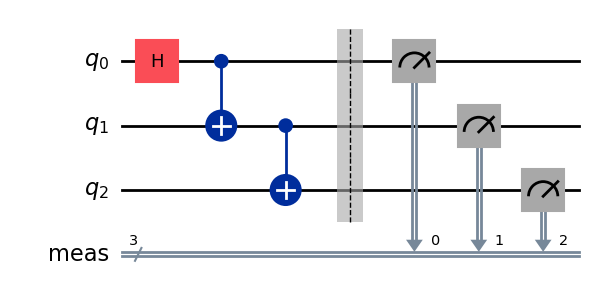

GHZ circuit AFTER transpiling.


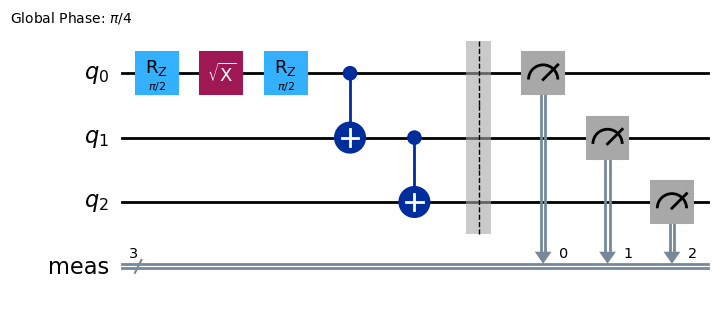

In [ ]:
num_qb = 3
ghz = create_ghz(num_qb)

ghz_trans = transpile(ghz, basis_gates=basis_gates)

print('GHZ circuit BEFORE transpiling.')
display(ghz.draw("mpl"))

print('GHZ circuit AFTER transpiling.')
display(ghz_trans.draw("mpl"))

### Circuit Folding

Original Depth (d): 9
Folded Depth: 59
Theoretical Scaling: 6.555555555555555

GHZ circuit BEFORE circuit folding.


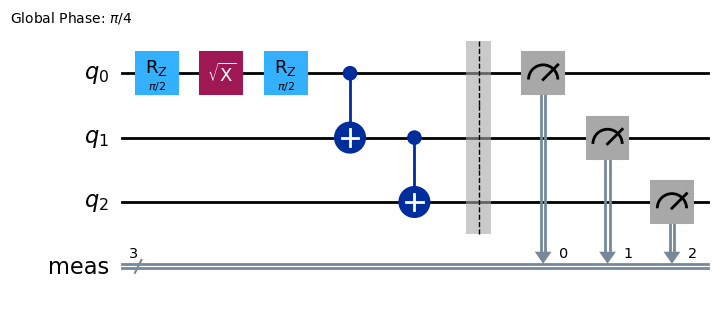

GHZ circuit AFTER circuit folding.


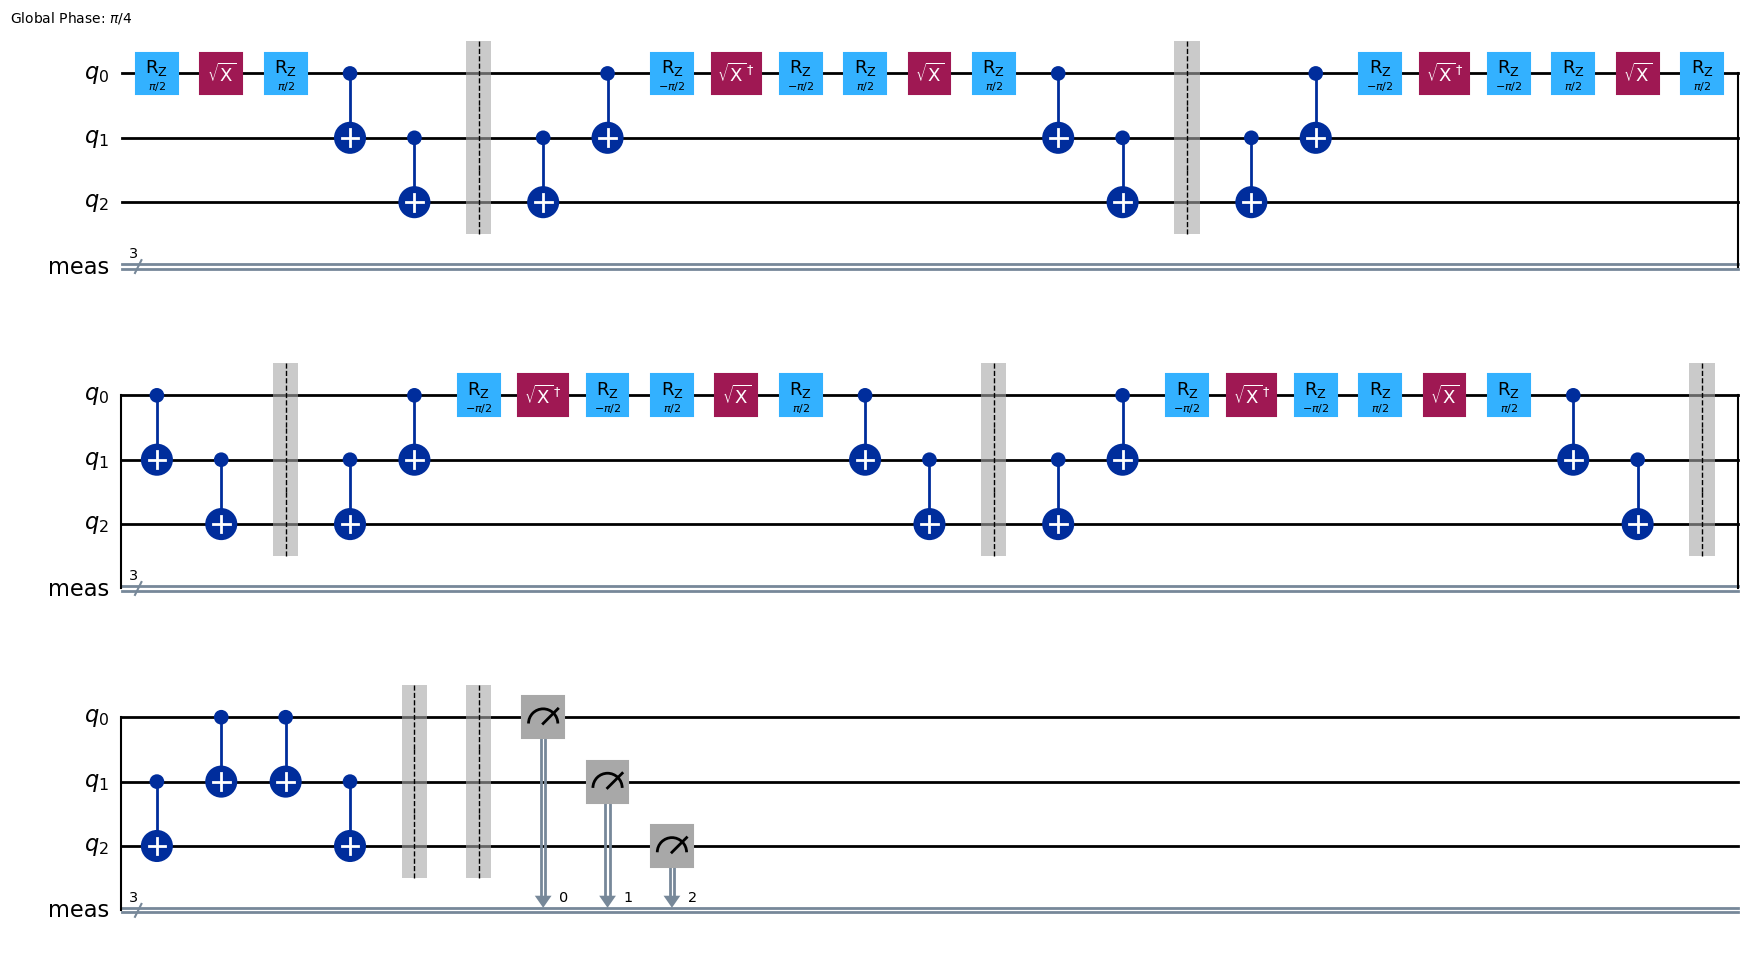

In [ ]:
ghz_circuit_folded = circuit_folding(ghz_trans, scale_factor=10)

print(f"Original Depth (d): {len(ghz_trans)}")
print(f"Folded Depth: {len(ghz_circuit_folded)}")
print(f"Theoretical Scaling: {len(ghz_circuit_folded)/len(ghz_trans)}")

print("\nGHZ circuit BEFORE circuit folding.")
display(ghz_trans.draw("mpl"))

print("GHZ circuit AFTER circuit folding.")
display(ghz_circuit_folded.draw("mpl"))

### Layer Folding

Original Depth (d): 9
Folded Depth: 53
Theoretical Scaling: 5.888888888888889

GHZ circuit BEFORE circuit folding.


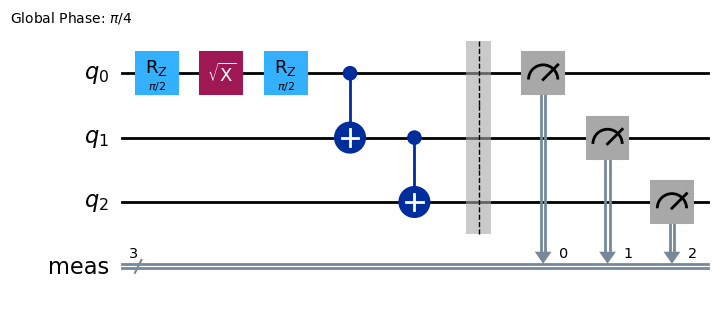

GHZ circuit AFTER circuit folding.


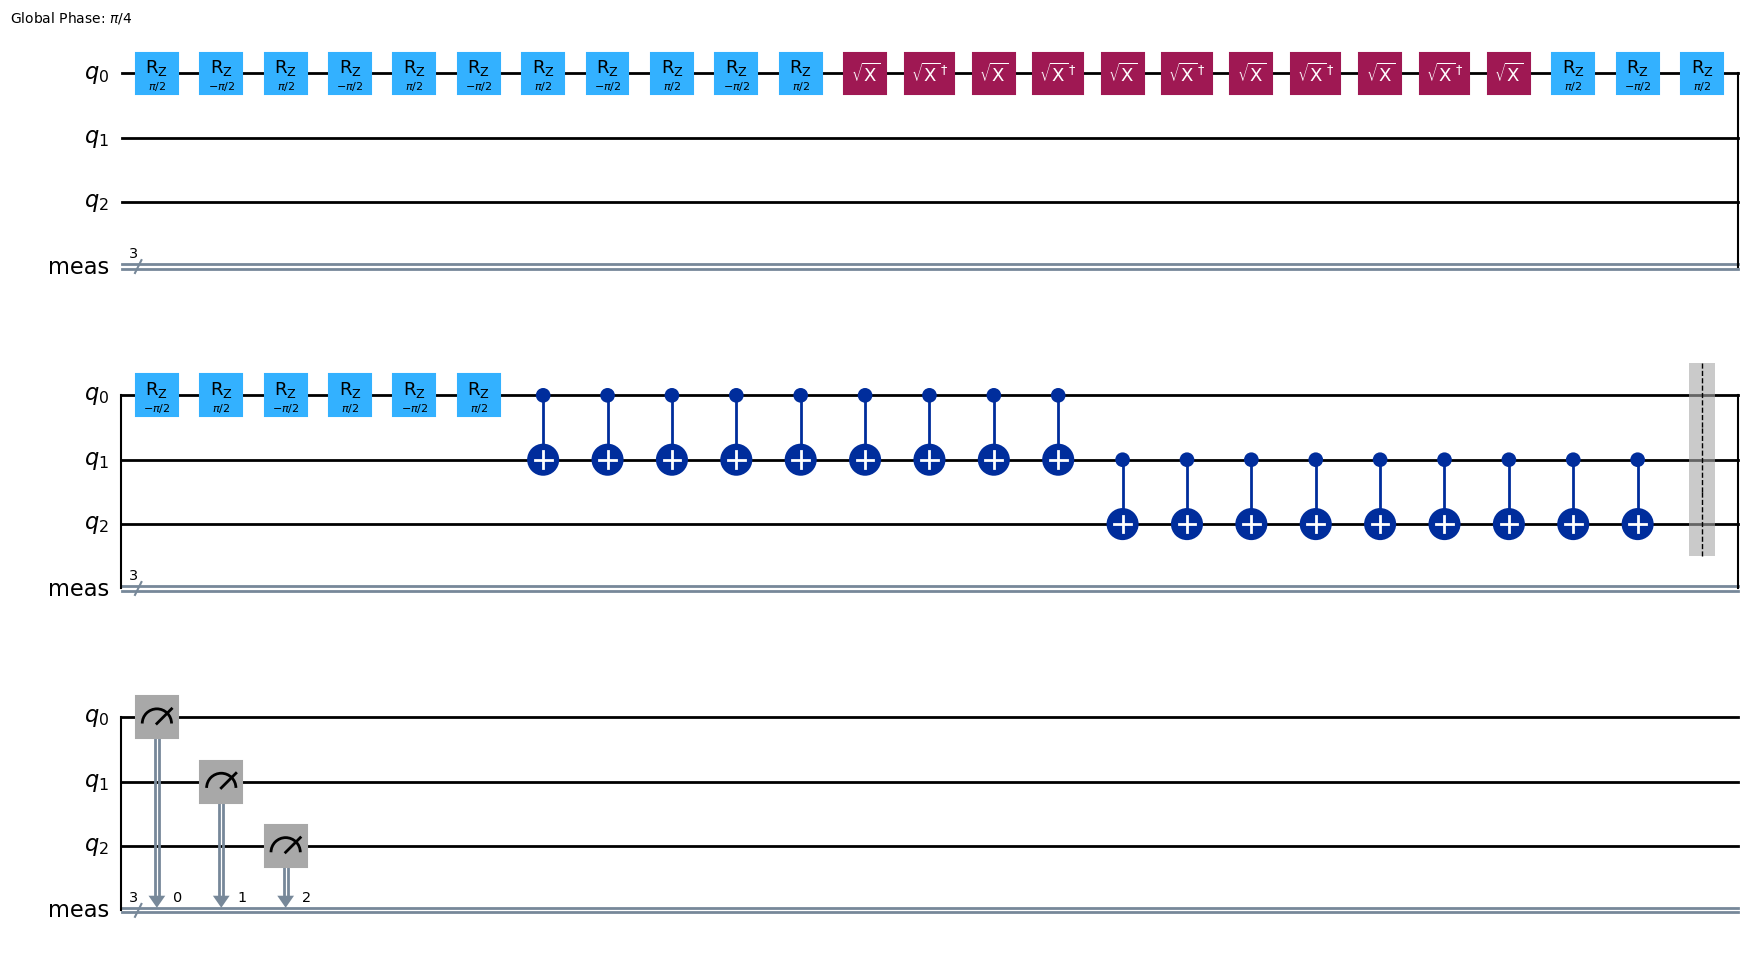

In [ ]:
ghz_layer_folded = layer_folding(ghz_trans, scale_factor=10, method='left')

print(f"Original Depth (d): {len(ghz_trans)}")
print(f"Folded Depth: {len(ghz_layer_folded)}")
print(f"Theoretical Scaling: {len(ghz_layer_folded)/len(ghz_trans)}")

print("\nGHZ circuit BEFORE circuit folding.")
display(ghz_trans.draw("mpl"))

print("GHZ circuit AFTER circuit folding.")
display(ghz_layer_folded.draw("mpl"))

## Run Circuits

In [ ]:
def run_circuit(qc, title, my_backend):
    results = my_backend.run(qc, shots=SHOTS).result()
    answer = results.get_counts()

    plt.suptitle(f"Results of {title}")
    plt.bar(answer.keys(), answer.values(), color='royalblue')
    plt.show()

    print(f"{title}: {answer}")
    return answer


def grover_results_noiseless():
    # Transpiled, no folding
    run_circuit(grover_trans, "Grover's algorithm - noiseless", backend)

    # Circuit folding
    run_circuit(grover_circuit_folded, "Grover's algorithm (Circuit Folding)- noiseless", backend)

    # Layer folding
    run_circuit(grover_circuit_folded, "Grover's algorithm (Layer Folding)- noiseless", backend)


def grover_results_noise(backend_noise):
    # Transpiled, no folding
    run_circuit(grover_trans, "Grover's algorithm - noiseless", backend_noise)

    # Circuit folding
    run_circuit(grover_circuit_folded, "Grover's algorithm (Circuit Folding)- noiseless", backend_noise)

    # Layer folding
    run_circuit(grover_circuit_folded, "Grover's algorithm (Layer Folding)- noiseless", backend_noise)


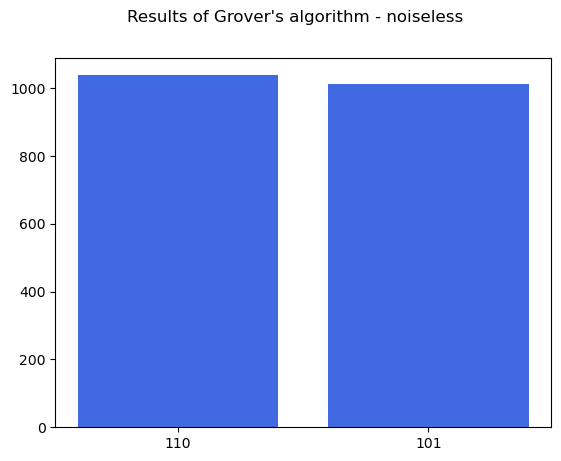

Grover's algorithm - noiseless: {'110': 1037, '101': 1011}


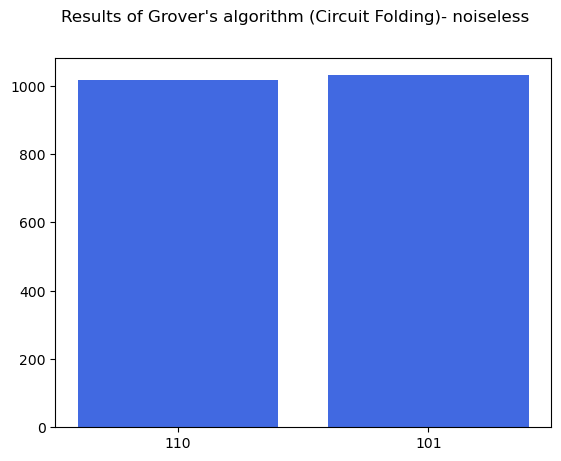

Grover's algorithm (Circuit Folding)- noiseless: {'110': 1017, '101': 1031}


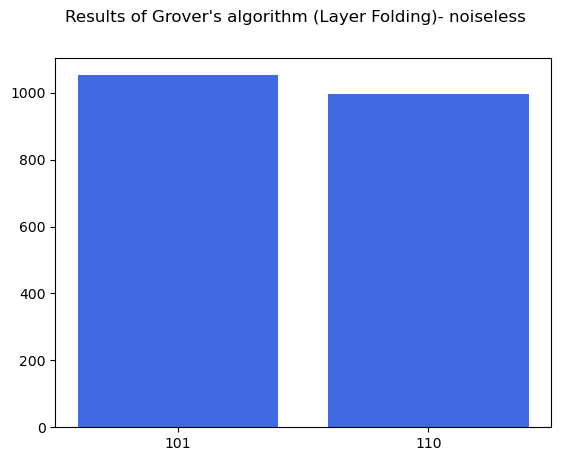

Grover's algorithm (Layer Folding)- noiseless: {'101': 1052, '110': 996}


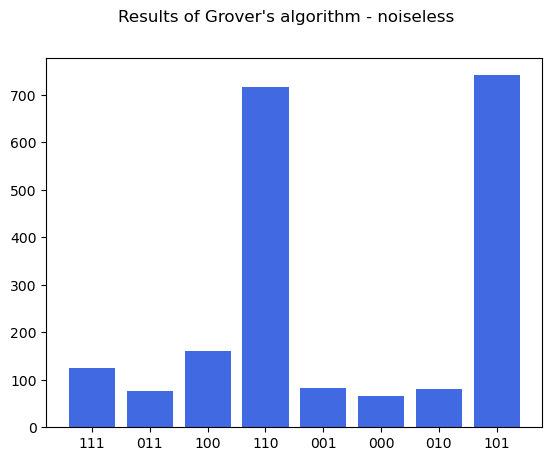

Grover's algorithm - noiseless: {'111': 124, '011': 77, '100': 160, '110': 717, '001': 83, '000': 65, '010': 81, '101': 741}


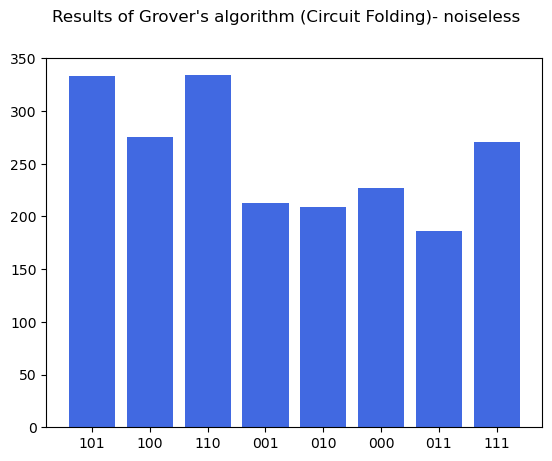

Grover's algorithm (Circuit Folding)- noiseless: {'101': 333, '100': 275, '110': 334, '001': 213, '010': 209, '000': 227, '011': 186, '111': 271}


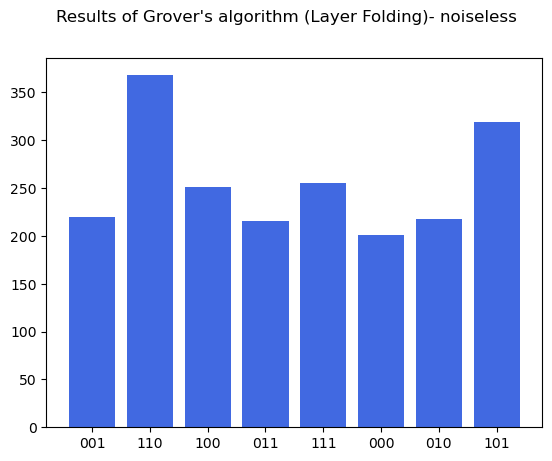

Grover's algorithm (Layer Folding)- noiseless: {'001': 220, '110': 368, '100': 251, '011': 216, '111': 255, '000': 201, '010': 218, '101': 319}


In [ ]:
grover_results_noiseless()
grover_results_noise(backend_noise=backend_noise_1)